In [1]:
!pip install -Uq pymcel

In [2]:
import pymcel as pc

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


In [3]:
!pip install -Uq numpy

In [4]:
import numpy as np

In [5]:
from datetime import datetime
hoy=datetime.now()

In [6]:
fecha_actual = datetime.now()

In [11]:
tabla, jd, X_sol = pc.consulta_horizons(
    id='Sun',
    location='@SSB',
    epochs='2026-02-26 00:00:00'
)
X_sol

array([-3.99267884e+08, -8.24090450e+08,  1.85429947e+07,  1.22108229e+01,
        1.23932702e+00, -2.42604119e-01])

In [16]:
tabla_jupiter,jd_jupiter,X_jupiter=pc.consulta_horizons(
    id='Jupiter barycenter',
    location= '@SSB',
    epochs='2026-02-26 00:00:00'
    )
X_jupiter

array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09, -1.21253772e+04,
       -4.61863891e+03,  2.90510926e+02])

In [18]:
r_sol_0 = X_sol[:3]
v_sol_0 = X_sol[3:]

r_jupiter_0 = X_jupiter[:3]
v_jupiter_0 = X_jupiter[3:]

In [19]:
deltat = 1 * 86400 # un día en segundos
r_jupiter_dt = r_jupiter_0 + v_jupiter_0 * deltat
r_sol_dt = r_sol_0 + v_sol_0 * deltat

r_jupiter_0, r_jupiter_dt

(array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09]),
 array([-3.14547192e+11,  7.16132604e+11,  4.06889651e+09]))

In [20]:
mu_sol = pc.constantes.mu_sun
mu_jupiter = pc.constantes.mu_jupiter
rij_vec = r_jupiter_0 - r_sol_0
v_jup_dt = v_jupiter_0 - mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_jup_dt

array([-12117.89040582,  -4635.79206931,    290.41467508])

In [21]:
rij_vec_sol = r_sol_0 - r_jupiter_0         
v_sol_dt = v_sol_0 - mu_jupiter * rij_vec_sol / np.linalg.norm(rij_vec_sol)**3 * deltat

v_sol_dt

array([12.2036746 ,  1.25570472, -0.24251222])

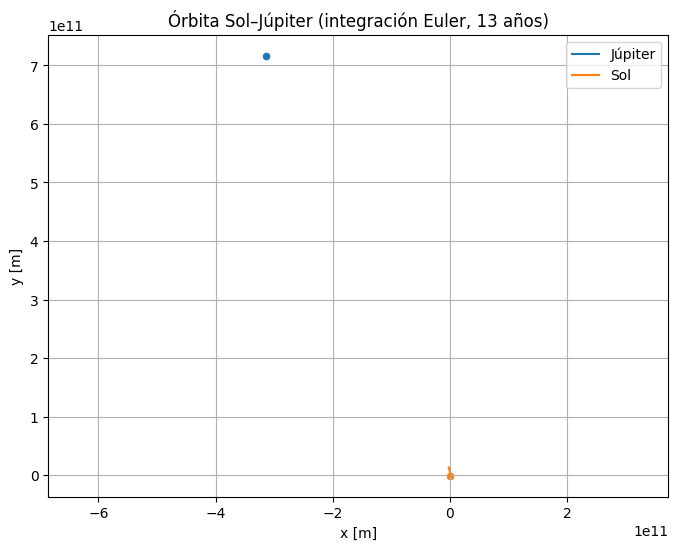

In [29]:
import matplotlib.pyplot as plt

years = 12
sec_year = 365.25 * 86400
T_total = years * sec_year

N_steps = int(T_total // deltat)

r_jupiter = r_jupiter_0.copy()
v_jupiter = v_jupiter_0.copy()

r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()

# Listas para guardar la trayectoria
r_jup_hist = []
r_sol_hist = []

for _ in range(N_steps):
    
    r_jup_hist.append(r_jupiter.copy())
    r_sol_hist.append(r_sol.copy())

    # Vector de separación Júpiter - Sol
    rij = r_jupiter - r_sol
    r = np.linalg.norm(rij)

    # Aceleraciones mutuas (dos cuerpos)
    a_jup = -mu_sol * rij / r**3
    a_sol =  mu_jupiter * rij / r**3  # misma dirección, signo contrario y masa diferente

    # Integración tipo Euler (mismo esquema que usaste antes)
    v_jup = v_jupiter + a_jup * deltat
    r_jup = r_jupiter + v_jup * deltat

    v_sol = v_sol + a_sol * deltat
    r_sol = r_sol + v_sol * deltat

r_jup_hist = np.array(r_jup_hist)
r_sol_hist = np.array(r_sol_hist)

# Gráfica de órbita en el plano XY
plt.figure(figsize=(8, 6))
plt.plot(r_jup_hist[:, 0], r_jup_hist[:, 1], label="Júpiter", color="tab:blue")
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")

# Marcamos posiciones iniciales
plt.scatter(r_jupiter_0[0], r_jupiter_0[1], color="tab:blue", s=20, marker="o")
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=20, marker="o")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbita Sol–Júpiter (integración Euler, 13 años)")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

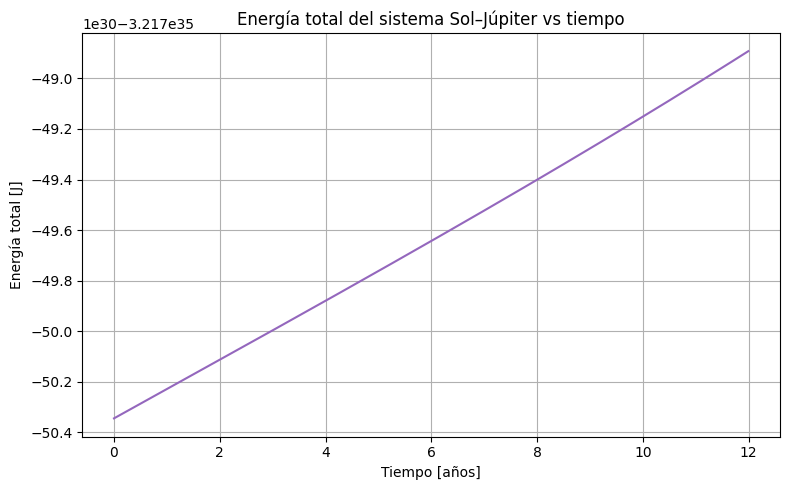

In [31]:
G = 6.67430e-11  # m^3 kg^-1 s^-2
M_sol = mu_sol / G
M_jup = mu_jupiter / G

# Tiempo asociado a cada paso (en segundos y en años)
t_array = np.arange(N_steps) * deltat          # s
t_years = t_array / sec_year          # años

# Posición relativa Júpiter–Sol en cada instante
r_rel = r_jup_hist - r_sol_hist               # vector r_jup - r_sol
r_norm = np.linalg.norm(r_rel, axis=1)        # distancia |r|

# Energía potencial gravitatoria (dos cuerpos)
U = -G * M_sol * M_jup / r_norm               # J

# Velocidades relativas aproximadas por diferencias finitas hacia adelante
v_jup_hist = np.diff(r_jup_hist, axis=0) / deltat
v_sol_hist = np.diff(r_sol_hist, axis=0) / deltat

# Igualamos longitud de arrays de energía recortando el último paso en U
U = U[:-1]
t_years_energy = t_years[:-1]

# Energías cinéticas
K_jup = 0.5 * M_jup * np.sum(v_jup_hist**2, axis=1)
K_sol = 0.5 * M_sol * np.sum(v_sol_hist**2, axis=1)

E_total = K_jup + K_sol + U    # energía total

plt.figure(figsize=(8, 5))
plt.plot(t_years_energy, E_total, color="tab:purple")
plt.xlabel("Tiempo [años]")
plt.ylabel("Energía total [J]")
plt.title("Energía total del sistema Sol–Júpiter vs tiempo")
plt.grid(True)
plt.tight_layout()
plt.show()